# Mic Input Processing


## 1. Import Required Libraries

In [108]:
# Import libraries for audio processing, visualization, and database operations
import matplotlib.pyplot as plt
from pathlib import Path
import time
import numpy as np

from audio_processing.audio import load_audio, record_audio, lowpass_filter, highpass_filter, bandpass_filter
from audio_processing.spectrogram import spectrogram, find_peaks
from controllers.database import connect, init_db
from controllers.fingerprint import generate_fingerprints
from controllers.song_manager import persist_song_data

In [40]:
# Record audio from the microphone
for i in range(3, 0, -1):
    print(f"\r--- Recording starts in {i} seconds ---")
    time.sleep(0.5)
print("Recording now...")
y_mic, sr_mic = record_audio(duration=7)
print("Recording done.")
print(f"Shape of input: {y_mic.shape}")

# Debug: Check the audio levels
print(f"Audio min: {y_mic.min():.6f}, max: {y_mic.max():.6f}")
print(f"Audio mean: {y_mic.mean():.6f}, std: {y_mic.std():.6f}")

# Normalize audio before saving if levels are too low
y_mic_normalized = y_mic / np.max(np.abs(y_mic)) * 0.95  # Normalize to 95% of max int16

# Save audio to file
mic_output_file = Path("data", "assets", "mic_recordings", "mic_recording.wav")
from scipy.io.wavfile import write
write(mic_output_file.as_posix(), sr, (y_mic_normalized * 32767).astype('int16'))
print(f"Saved mic recording to {mic_output_file.as_posix()}")

# Load and verify what was saved
from scipy.io.wavfile import read
sr_test, y_test = read(mic_output_file.as_posix())
print(f"Verified saved file - min: {y_test.min()}, max: {y_test.max()}")

--- Recording starts in 3 seconds ---
--- Recording starts in 2 seconds ---
--- Recording starts in 1 seconds ---
Recording now...
Recording done.
Shape of input: (154350,)
Audio min: -0.267283, max: 0.236404
Audio mean: -0.000002, std: 0.047676
Saved mic recording to data/assets/mic_recordings/mic_recording.wav
Verified saved file - min: -31128, max: 27532


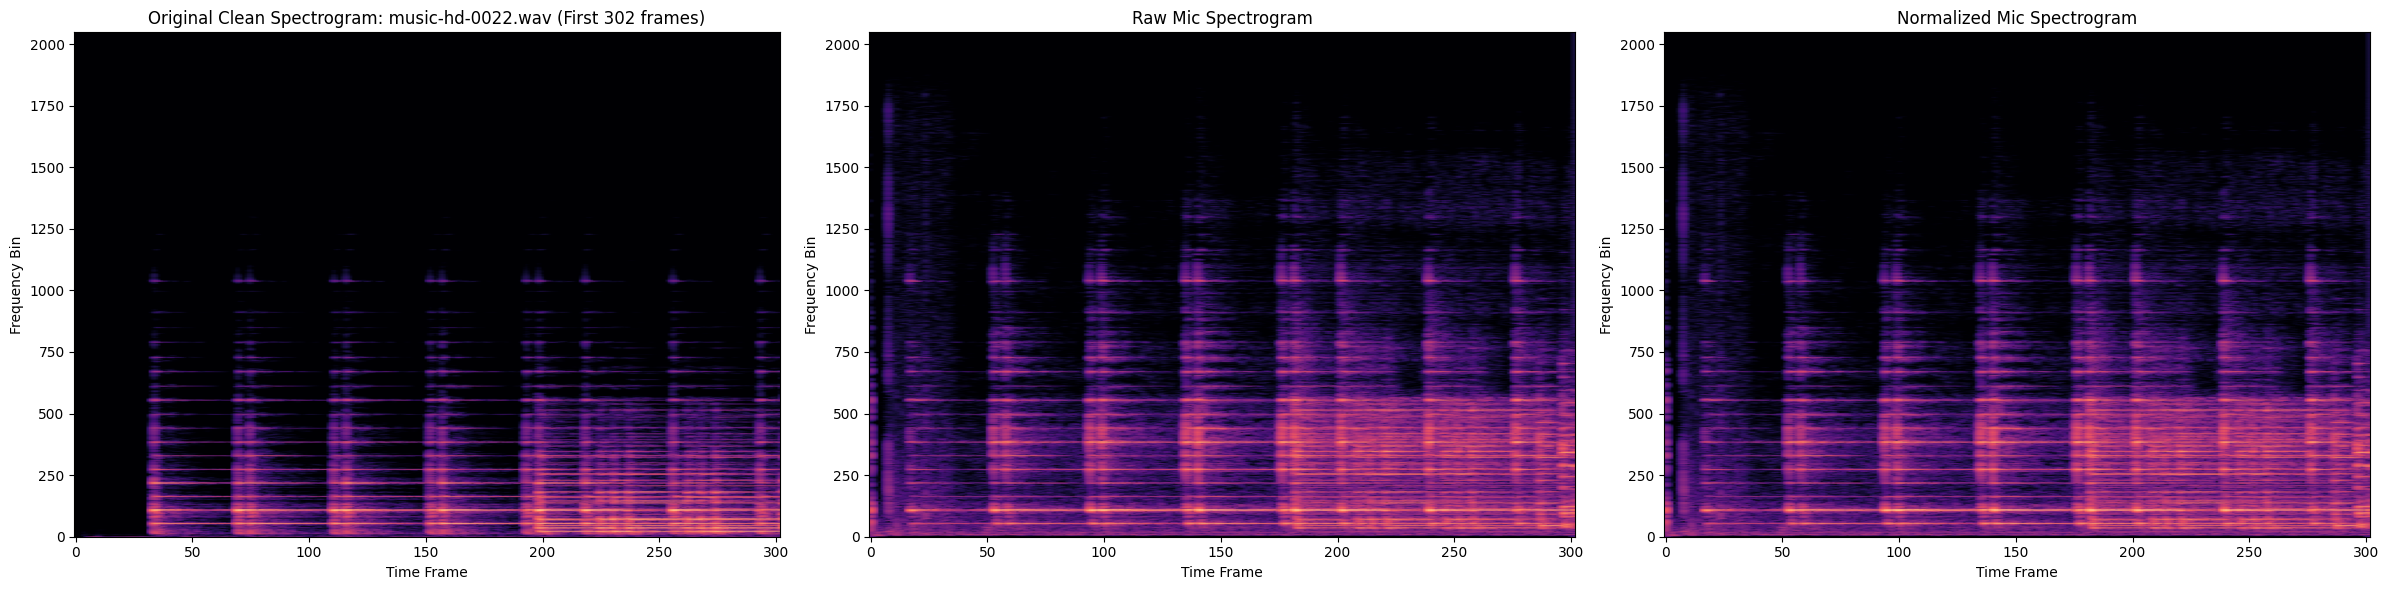

In [110]:
# Compute spectrograms
from config import DEFAULT_SR

S_db_orig = spectrogram(y_orig)
S_db_mic = spectrogram(y_mic)
S_db_mic_normalized = spectrogram(y_mic_normalized)

# Slice original to match mic length
mic_time_frames = S_db_mic.shape[1]
S_db_original_slice = S_db_orig[:, :mic_time_frames]

# Show side-by-side spectrograms
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

axes[0].imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Original Clean Spectrogram: {original_file.name} (First {mic_time_frames} frames)")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")

axes[1].imshow(S_db_mic, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Raw Mic Spectrogram")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")

axes[2].imshow(S_db_mic_normalized, aspect="auto", origin="lower", cmap="magma")
axes[2].set_title("Normalized Mic Spectrogram")
axes[2].set_xlabel("Time Frame")
axes[2].set_ylabel("Frequency Bin")

plt.tight_layout()
plt.show()

# Define other variables
sr_mic = DEFAULT_SR
amp_min = -60
noise_length = int(0.5 * sr_mic)
if len(y_mic) > noise_length:
    noise_clip = y_mic[:noise_length]
else:
    noise_clip = y_mic

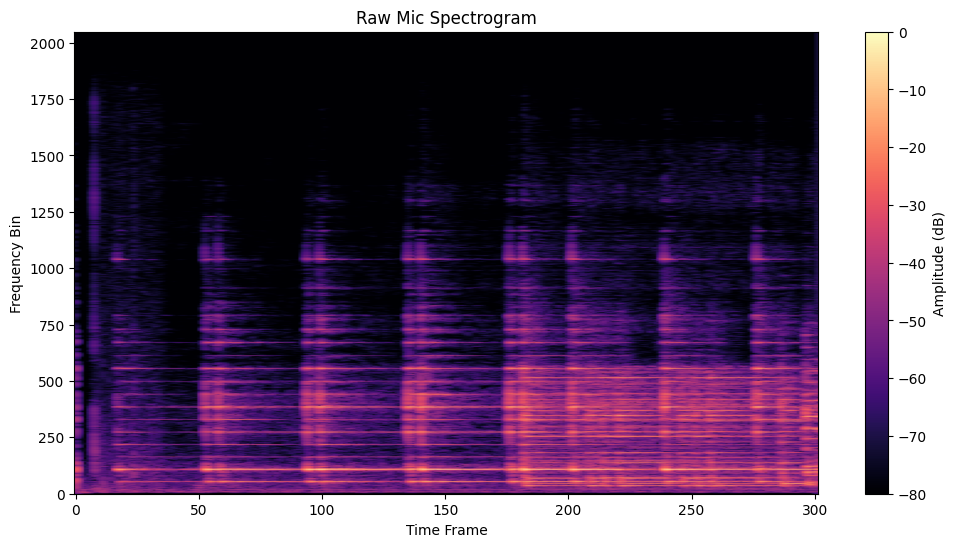

In [111]:
# 1. Raw Mic Spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title("Raw Mic Spectrogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

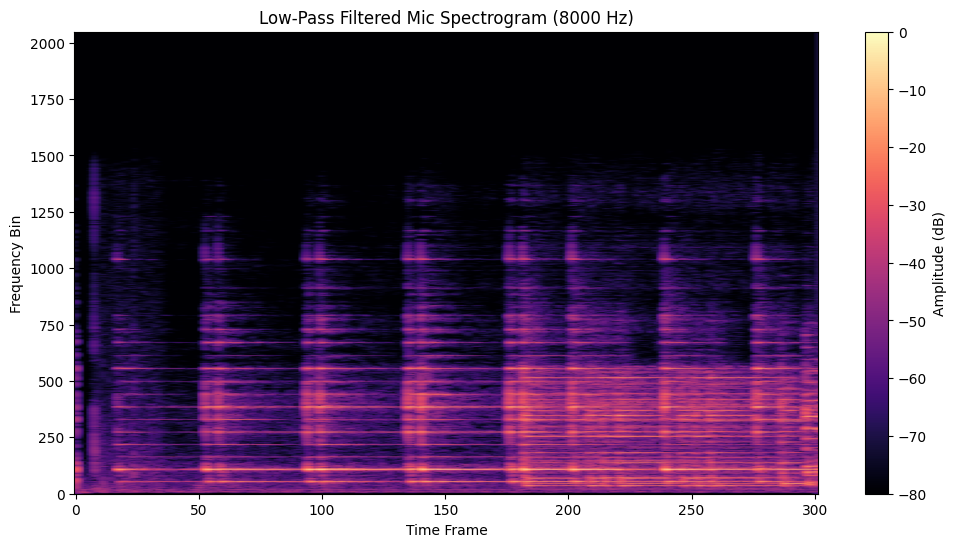

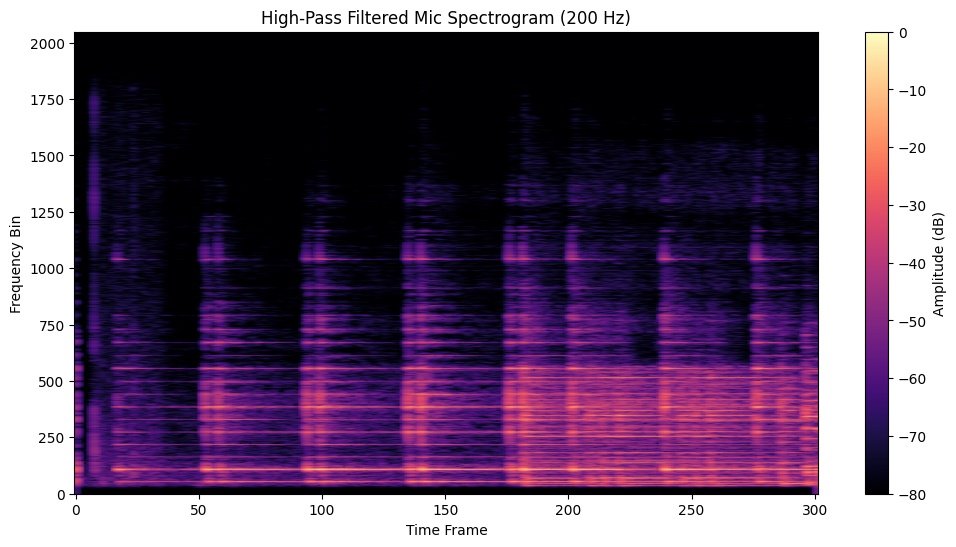

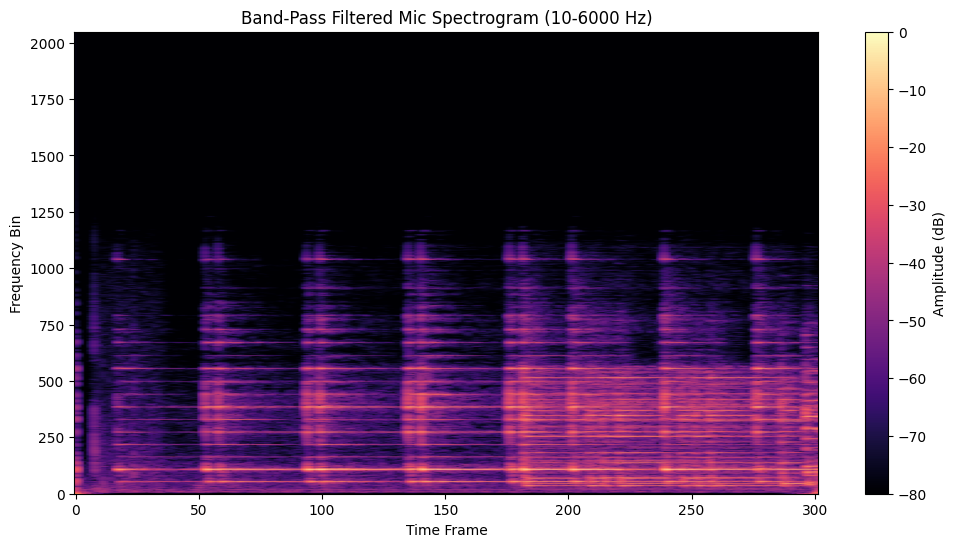

In [112]:
# 2. Low-Pass Filtered (removes high frequencies)
cutoff_low = 8000  # Hz
y_mic_lowpass = lowpass_filter(y_mic, cutoff_low, sr_mic)
S_db_mic_lowpass = spectrogram(y_mic_lowpass)

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_lowpass, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Low-Pass Filtered Mic Spectrogram ({cutoff_low} Hz)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

cutoff_high = 200  # Hz
y_mic_highpass = highpass_filter(y_mic, cutoff_high, sr_mic)
S_db_mic_highpass = spectrogram(y_mic_highpass)

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_highpass, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"High-Pass Filtered Mic Spectrogram ({cutoff_high} Hz)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

lowcut = 10  # Hz
highcut = 6000  # Hz
y_mic_bandpass = bandpass_filter(y_mic, lowcut, highcut, sr_mic)
S_db_mic_bandpass = spectrogram(y_mic_bandpass)

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_bandpass, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Band-Pass Filtered Mic Spectrogram ({lowcut}-{highcut} Hz)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

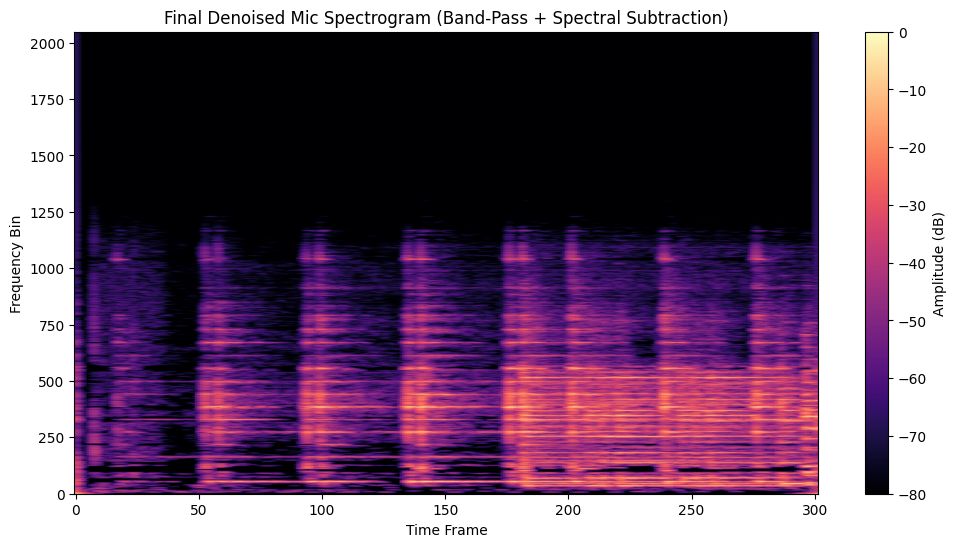

In [113]:
# 5. Spectral Subtraction (noise reduction)
import librosa
import numpy as np

default_hop_length = 512
# Using the band-pass filtered as base for denoising
mic_stft = librosa.stft(y_mic_bandpass)
noise_stft = librosa.stft(noise_clip)
noise_power = np.mean(np.abs(noise_stft)**2, axis=1)

mic_stft_denoised = mic_stft - noise_power[:, np.newaxis] * 0.5
mic_stft_denoised = np.maximum(mic_stft_denoised, 0)

y_mic_final = librosa.istft(mic_stft_denoised, hop_length=default_hop_length)
S_db_mic_final = spectrogram(y_mic_final)

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_final, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title("Final Denoised Mic Spectrogram (Band-Pass + Spectral Subtraction)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

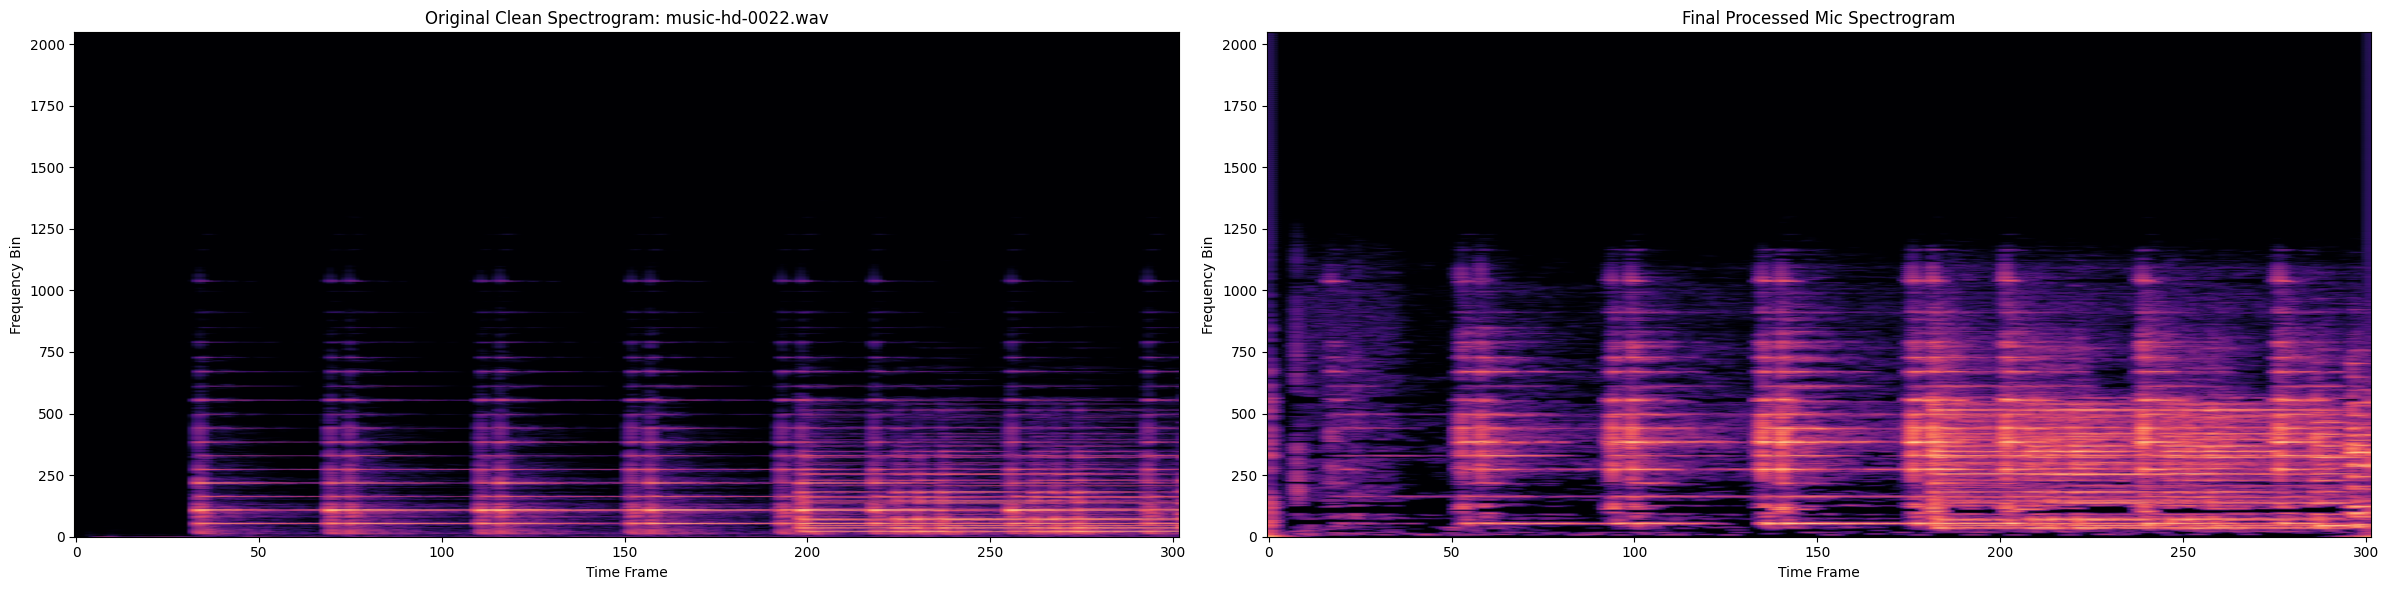

Original max dB: -5.42, Final Mic max dB: 0.00
Original min dB: -80.00, Final Mic min dB: -80.00


In [114]:
# 6. Comparison: Final Processed Mic vs. Original Clean Spectrogram
fig, axes = plt.subplots(1, 2, figsize=(24, 6))

# Original clean spectrogram (sliced)
axes[0].imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Original Clean Spectrogram: {original_file.name}")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")

# Final processed mic spectrogram
axes[1].imshow(S_db_mic_final, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Final Processed Mic Spectrogram")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")

plt.tight_layout()
plt.show()

# Print stats
print(f"Original max dB: {np.max(S_db_original_slice):.2f}, Final Mic max dB: {np.max(S_db_mic_final):.2f}")
print(f"Original min dB: {np.min(S_db_original_slice):.2f}, Final Mic min dB: {np.min(S_db_mic_final):.2f}")

Shape of original slice: (2049, 302), max dB: -5.42, min dB: -80.00
Shape of final mic slice: (2049, 302), max dB: 0.00, min dB: -80.00
Original enhanced peaks: 222, Mic enhanced peaks: 478, Mic raw peaks: 426, Low-bin peaks: 254


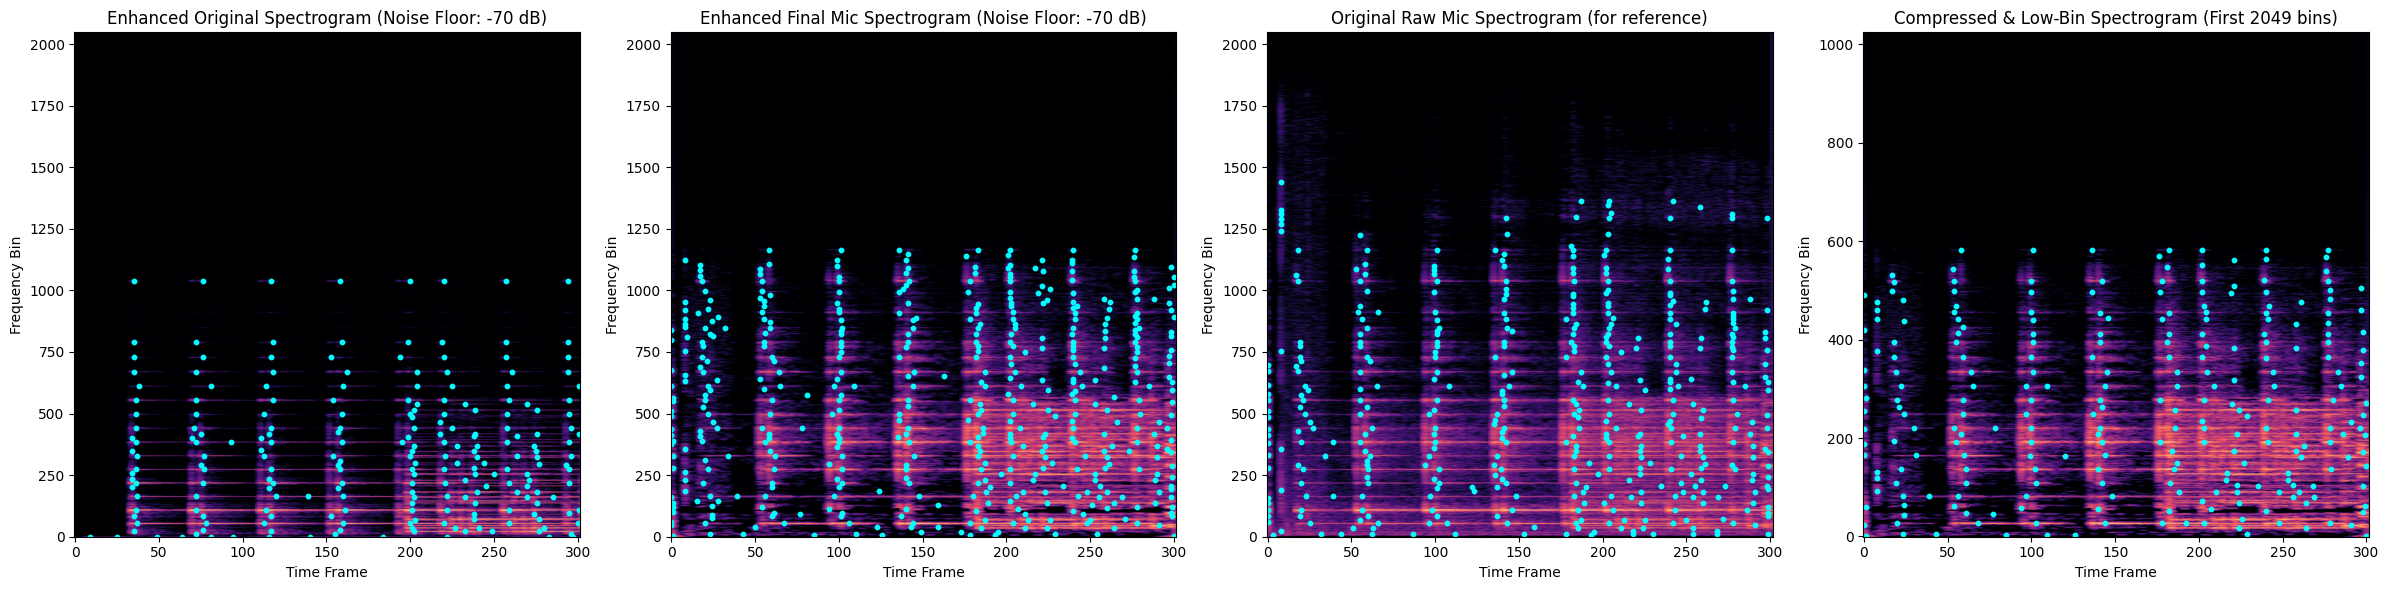

Matching fingerprints with enhanced spectrograms: 0


In [115]:
# Enhance Peaks: Apply a noise floor to make peaks more evident by reducing background noise
noise_floor_db = -70  # dB; adjust to set the minimum level

# Apply to original
S_db_original_enhanced = np.maximum(S_db_original_slice, noise_floor_db)
S_db_original_enhanced = S_db_original_slice
print(f"Shape of original slice: {S_db_original_slice.shape}, max dB: {np.max(S_db_original_slice):.2f}, min dB: {np.min(S_db_original_slice):.2f}")
# Apply to final processed mic
S_db_mic_enhanced = np.maximum(S_db_mic_final, noise_floor_db)
print(f"Shape of final mic slice: {S_db_mic_final.shape}, max dB: {np.max(S_db_mic_final):.2f}, min dB: {np.min(S_db_mic_final):.2f}")

# Compress frequency bins (downsample by factor of 2)
S_db_compressed = S_db_mic_enhanced[::2, :]  # Take every 2nd frequency bin
# Restrict peak detection to lower bins (e.g., first 100 bins)
# Get number of bin in the original spectrogram
num_bins_original = S_db_original_slice.shape[0]
num_bins = num_bins_original
S_db_low = S_db_compressed[:num_bins, :]
peaks_low = find_peaks(S_db_low, amp_min=amp_min)

# Visualize enhanced versions
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(S_db_original_enhanced, aspect="auto", origin="lower", cmap="magma", vmin=noise_floor_db, vmax=np.max(S_db_original_enhanced))
axes[0].set_title(f"Enhanced Original Spectrogram (Noise Floor: {noise_floor_db} dB)")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")

axes[1].imshow(S_db_mic_enhanced, aspect="auto", origin="lower", cmap="magma", vmin=noise_floor_db, vmax=np.max(S_db_mic_enhanced))
axes[1].set_title(f"Enhanced Final Mic Spectrogram (Noise Floor: {noise_floor_db} dB)")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")

axes[2].imshow(S_db_mic, aspect="auto", origin="lower", cmap="magma")
axes[2].set_title("Original Raw Mic Spectrogram (for reference)")
axes[2].set_xlabel("Time Frame")
axes[2].set_ylabel("Frequency Bin")

axes[3].imshow(S_db_low, aspect="auto", origin="lower", cmap="magma", vmin=noise_floor_db, vmax=np.max(S_db_low))
axes[3].set_title(f"Compressed & Low-Bin Spectrogram (First {num_bins} bins)")
axes[3].set_xlabel("Time Frame")
axes[3].set_ylabel("Frequency Bin")

# Recompute peaks with enhanced spectrograms for better detection
peaks_original_enhanced = find_peaks(S_db_original_enhanced, amp_min=amp_min)
peaks_mic_enhanced = find_peaks(S_db_mic_enhanced, amp_min=amp_min)
peaks_mic_raw = find_peaks(S_db_mic, amp_min=amp_min)

times, freqs = zip(*peaks_original_enhanced)
axes[0].scatter(times, freqs, s=10, c="cyan", label="Peaks")
times, freqs = zip(*peaks_mic_enhanced)
axes[1].scatter(times, freqs, s=10, c="cyan", label="Peaks")
times, freqs = zip(*peaks_mic_raw)
axes[2].scatter(times, freqs, s=10, c="cyan", label="Peaks")
times, freqs = zip(*peaks_low)
axes[3].scatter(times, freqs, s=10, c="cyan", label="Peaks")
print(f"Original enhanced peaks: {len(peaks_original_enhanced)}, Mic enhanced peaks: {len(peaks_mic_enhanced)}, Mic raw peaks: {len(peaks_mic_raw)}, Low-bin peaks: {len(peaks_low)}")


plt.tight_layout()
plt.show()

fps_original_enhanced = generate_fingerprints(peaks_original_enhanced)
fps_mic_enhanced = generate_fingerprints(peaks_mic_enhanced)
fps_mic_raw = generate_fingerprints(peaks_mic_raw)
fps_mic_low = generate_fingerprints(peaks_low)


matches_enhanced = set((h, offset) for h, offset in fps_original_enhanced) & set((h, offset) for h, offset in fps_mic_enhanced)
print(f"Matching fingerprints with enhanced spectrograms: {len(matches_enhanced)}")

# Update fingerprints to enhanced version
fingerprints = fps_mic_enhanced

In [116]:
import controllers.match_service as match_service
match_service = match_service.MatchService()
conn = connect()
init_db(conn)
match_service.conn = conn
matches = match_service.match_fingerprints(fps_original_enhanced)
print(f"ENHANCED SPECTROGRAMS: {len(matches)}")
matches = match_service.match_fingerprints(fps_mic_raw)
print(f"RAW SPECTROGRAM: {len(matches)}")
matches = match_service.match_fingerprints(fps_mic_low)
print(f"COMPRESSED LOW-BIN SPECTROGRAM: {(matches)}")

Recognizing audio from 1518 fingerprints...

Total songs in DB: 27

Best match: music-hd-0022 with score 3654

ENHANCED SPECTROGRAMS: 2


Recognizing audio from 2808 fingerprints...

...

RAW SPECTROGRAM: 2


Recognizing audio from 1608 fingerprints...

Total songs in DB: 27

Best match: music-hd-0022 with score 27

COMPRESSED LOW-BIN SPECTROGRAM: None


In [117]:
# Load original clean 0022 audio
original_file = Path("data", "assets", "clean_wavs", "music-hd-0002.wav")
y_orig, sr_orig = load_audio(original_file.as_posix())

print(f"Loaded {original_file.name}, Sample Rate: {sr_orig}, Audio Length: {len(y_orig)/sr_orig:.2f} seconds")

# Debug: Check the audio levels
print(f"Audio min: {y_orig.min():.6f}, max: {y_orig.max():.6f}")
print(f"Audio mean: {y_orig.mean():.6f}, std: {y_orig.std():.6f}")


Loaded music-hd-0002.wav, Sample Rate: 22050, Audio Length: 134.49 seconds
Audio min: -0.887573, max: 0.999969
Audio mean: -0.000721, std: 0.121166
